<a href="https://colab.research.google.com/github/zaima-sohail/Deep_learning_projects/blob/main/Toxic_Comment_Classification%20using%20CNN%20Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


load the csv file using read_csv

In [4]:
# Load the dataset
df = pd.read_csv("toxic_comments_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (30000, 15)


In [3]:
df.head()

,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
0,COM000001,The message targets a group unfairly and viola...,Identity_Attack,0,1,0,0,1,0.818,66,10,Community Chat,Sports,High,English
1,COM000002,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.069,58,9,News Comments,Entertainment,High,English
2,COM000003,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.622,44,7,Social Media,Politics,Low,English
3,COM000004,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.010,61,9,Social Media,Entertainment,Low,English
4,COM000005,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.140,52,8,Blog,Sports,Low,English


In [5]:
# Task 1: Dataset Loading and Initial Exploration

# Display first 10 records
print("First 10 Records:")
display(df.head(10))

# Display last 8 records
print("\nLast 8 Records:")
display(df.tail(8))

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

First 10 Records:


,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
0,COM000001,The message targets a group unfairly and viola...,Identity_Attack,0,1,0,0,1,0.818,66,10,Community Chat,Sports,High,English
1,COM000002,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.069,58,9,News Comments,Entertainment,High,English
2,COM000003,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.622,44,7,Social Media,Politics,Low,English
3,COM000004,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.010,61,9,Social Media,Entertainment,Low,English
4,COM000005,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.140,52,8,Blog,Sports,Low,English
5,COM000006,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.729,44,7,Social Media,Technology,Low,English
6,COM000007,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.193,52,8,Blog,Entertainment,Low,English
7,COM000008,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.183,61,9,Forum,Gaming,Low,English
8,COM000009,This article provides useful information and c...,Clean,1,0,0,0,0,0.142,60,8,Social Media,Education,Medium,English
9,COM000010,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.153,61,9,Forum,Entertainment,Low,English



Last 8 Records:


,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
29992,COM029993,Your message is unnecessarily hostile and offe...,Toxic,0,1,0,0,0,0.520,52,7,Forum,Gaming,Medium,English
29993,COM029994,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.195,61,9,News Comments,Sports,Medium,English
29994,COM029995,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.174,58,9,Community Chat,Gaming,Low,English
29995,COM029996,This article provides useful information and c...,Clean,1,0,0,0,0,0.013,60,8,Community Chat,Sports,Medium,English
29996,COM029997,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.050,52,8,Blog,Politics,Medium,English
29997,COM029998,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.078,61,9,Forum,Sports,Low,English
29998,COM029999,This article provides useful information and c...,Clean,1,0,0,0,0,0.003,60,8,Social Media,Sports,Medium,English
29999,COM030000,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.082,61,9,Community Chat,Education,High,English



Dataset Shape:
(30000, 15)


In [6]:

print("Column Names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)

Column Names:
Index(['Comment_ID', 'Comment_Text', 'Toxicity_Label', 'Clean', 'Toxic',
       'Severe_Toxic', 'Threat', 'Identity_Attack', 'Toxicity_Score',
       'Comment_Length', 'Word_Count', 'Platform', 'Topic',
       'Moderation_Priority', 'Language'],
      dtype='object')

Data Types:
Comment_ID              object
Comment_Text            object
Toxicity_Label          object
Clean                    int64
Toxic                    int64
Severe_Toxic             int64
Threat                   int64
Identity_Attack          int64
Toxicity_Score         float64
Comment_Length           int64
Word_Count               int64
Platform                object
Topic                   object
Moderation_Priority     object
Language                object
dtype: object


In [7]:
print("statisical summary:")
df.describe()

statisical summary:


,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.619300,0.380700,0.060033,0.048633,0.048933,0.324542,56.357633,8.340633
std,0.485567,0.485567,0.237553,0.215104,0.215732,0.302914,6.962596,0.972094
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.000000,6.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.079000,52.000000,8.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.161000,58.000000,8.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.624000,61.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.950000,71.000000,11.000000


In [8]:
df.isnull().sum()

,0
Comment_ID,0
Comment_Text,0
Toxicity_Label,0
Clean,0
Toxic,0
Severe_Toxic,0
Threat,0
Identity_Attack,0
Toxicity_Score,0
Comment_Length,0


In [10]:
print(df.duplicated().sum())

0


In [19]:
df = df.dropna(subset=["Comment_Text"]).copy()

In [20]:
# Convert comments to lowercase

df["Comment_Text"] = df["Comment_Text"].str.lower()

print(df["Comment_Text"].head())

0    the message targets a group unfairly and viola...
1    thank you for sharing this perspective with th...
2         that response is aggressive and not helpful.
3    i appreciate your explanation and the discussi...
4    i respectfully disagree but i understand your ...
Name: Comment_Text, dtype: object


In [21]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["cleaned_comment"] = df["Comment_Text"].apply(clean_text)

print(df[["Comment_Text", "cleaned_comment"]].head(10))

                                        Comment_Text  \
0  the message targets a group unfairly and viola...   
1  thank you for sharing this perspective with th...   
2       that response is aggressive and not helpful.   
3  i appreciate your explanation and the discussi...   
4  i respectfully disagree but i understand your ...   
5       that response is aggressive and not helpful.   
6  i respectfully disagree but i understand your ...   
7  i appreciate your explanation and the discussi...   
8  this article provides useful information and c...   
9  i appreciate your explanation and the discussi...   

                                     cleaned_comment  
0  the message targets a group unfairly and viola...  
1  thank you for sharing this perspective with th...  
2        that response is aggressive and not helpful  
3  i appreciate your explanation and the discussi...  
4  i respectfully disagree but i understand your ...  
5        that response is aggressive and not helpful 

In [22]:
print(df.columns)

Index(['Comment_ID', 'Comment_Text', 'Toxicity_Label', 'Clean', 'Toxic',
       'Severe_Toxic', 'Threat', 'Identity_Attack', 'Toxicity_Score',
       'Comment_Length', 'Word_Count', 'Platform', 'Topic',
       'Moderation_Priority', 'Language', 'cleaned_comment'],
      dtype='object')


In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

In [24]:
# Input and target

X = df["cleaned_comment"]
y = df["Toxicity_Label"]

# Split data into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 24000
Testing data: 6000


In [25]:
# Create tokenizer

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

print("Tokenizer created successfully!")
print("Total words:", len(tokenizer.word_index))


Tokenizer created successfully!
Total words: 86


In [26]:
# Convert training and testing text into sequences

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Training sequence example:")
print(X_train_seq[0])
# Maximum sequence length

max_length = 100

# Apply padding

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training padded shape:", X_train_pad.shape)
print("Testing padded shape:", X_test_pad.shape)

Training sequence example:
[3, 10, 51, 54, 55, 48, 2, 46, 47, 56]
Training padded shape: (24000, 100)
Testing padded shape: (6000, 100)


In [28]:

# STEP 1: Convert labels into numbers

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)

Classes: ['Clean' 'Identity_Attack' 'Severe_Toxic' 'Threat' 'Toxic']
Number of classes: 5


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Dense, Dropout, Flatten

In [30]:
model=Sequential()



In [38]:
model = Sequential() # Re-initialize the model
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 128

model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim)) # Removed input_length
model.add(Conv1D(64, 5, activation='relu'))
model.add(MaxPooling1D(pool_size=4))
model.add(Conv1D(128, 5, activation='relu'))
model.add(MaxPooling1D(pool_size=4))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

In [40]:

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:



history = model.fit(
    X_train_pad,
    y_train_encoded,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("Model training completed!")

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9556 - loss: 0.1217 - val_accuracy: 1.0000 - val_loss: 3.7082e-06
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9990 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 3.1029e-07
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9999 - loss: 4.2239e-04 - val_accuracy: 1.0000 - val_loss: 2.8866e-07
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9999 - loss: 2.8382e-04 - val_accuracy: 1.0000 - val_loss: 4.0392e-07
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9999 - loss: 3.2499e-04 - val_accuracy: 1.0000 - val_loss: 1.3982e-08
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9999 - loss: 1.0127e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9991 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 4.1227e-09
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accur

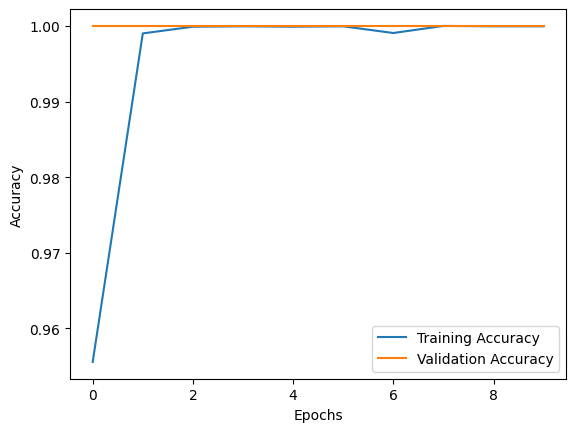

In [42]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [43]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test_encoded,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Loss: 0.0
Test Accuracy: 1.0
Test Accuracy (%): 100.0


In [44]:

# Classification Report

from sklearn.metrics import classification_report

# Predict test data
y_pred_probability = model.predict(X_test_pad)

# Convert probabilities into class numbers
y_pred = np.argmax(y_pred_probability, axis=1)

print("Classification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred,
        labels=range(num_classes),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Classification Report:
                 precision    recall  f1-score   support

          Clean       1.00      1.00      1.00      3716
Identity_Attack       1.00      1.00      1.00       293
   Severe_Toxic       1.00      1.00      1.00       360
         Threat       1.00      1.00      1.00       292
          Toxic       1.00      1.00      1.00      1339

       accuracy                           1.00      6000
      macro avg       1.00      1.00      1.00      6000
   weighted avg       1.00      1.00      1.00      6000



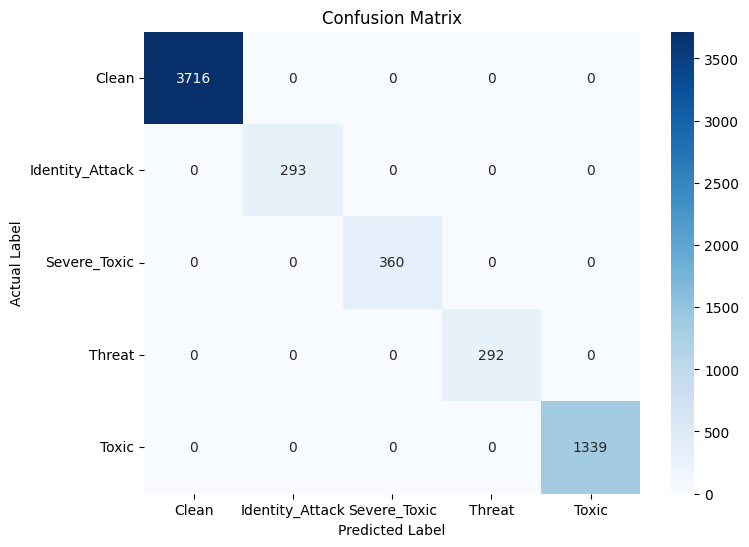

In [45]:

# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_encoded,
    y_pred,
    labels=range(num_classes)
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

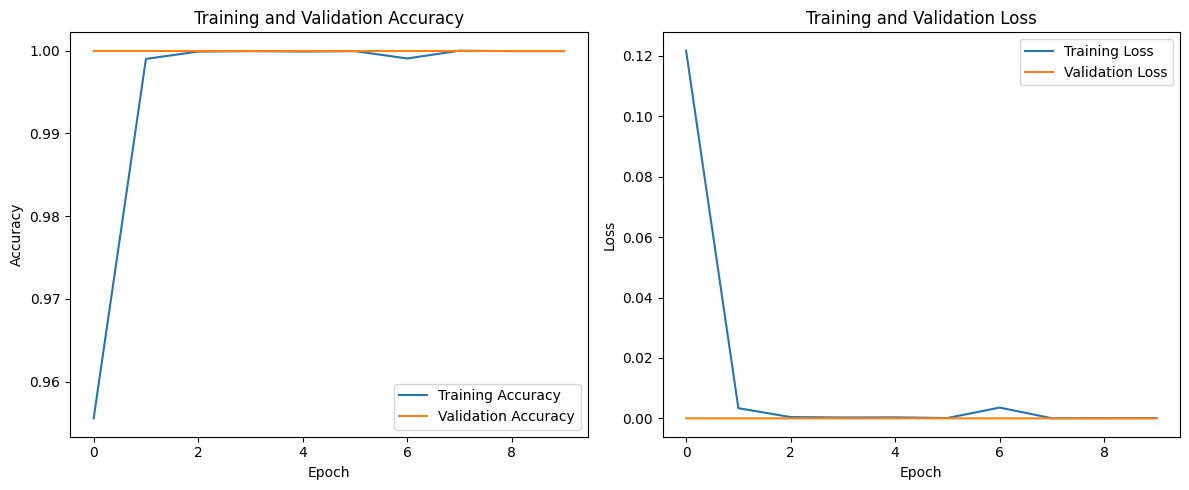

In [46]:

# Accuracy and Loss Curves

plt.figure(figsize=(12, 5))

# Accuracy graph
plt.subplot(1, 2, 1)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Create a synthetic new dataset for demonstration
data = {
    'Comment_ID': ['NEW001', 'NEW002', 'NEW003', 'NEW004', 'NEW005', 'NEW006', 'NEW007'],
    'Comment_Text': [
        'This is a clean and polite comment.',
        'You are a terrible person and should leave.',
        'I disagree with your point of view.',
        'Your ideas are utterly stupid and worthless.',
        'This article is very informative.',
        'I will find you and hurt you.',
        'Just another friendly remark.'
    ],
    'Toxicity_Label': [
        'Clean',
        'Toxic',
        'Clean',
        'Severe_Toxic',
        'Clean',
        'Threat',
        'Clean'
    ]
}

df_new_synthetic = pd.DataFrame(data)

# Save the synthetic DataFrame to a CSV file
df_new_synthetic.to_csv('new_toxic_comments_dataset.csv', index=False)

# Load the new, unseen dataset (which is now the synthetic one)
df_new = pd.read_csv('new_toxic_comments_dataset.csv')

print('Synthetic new dataset created and loaded successfully!')
print('New dataset shape:', df_new.shape)

# Display first 5 records of the new dataset
display(df_new.head())